In [43]:
# Load single timepoint ones

from glob import glob
from pathlib import Path
from re import findall
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt


In [123]:
# filelist

[]

In [127]:

dirname = Path('/Users/xies/OneDrive - Stanford/Skin/Two photon/NMS/Palbo senescence/11-01-2025 H2B FUCCI Palbo/M1 cage 5971/')
expt_name = ['Left ear/R2','Right ear/R2']

filelist = list(dirname.rglob( f'{expt_name[0]}/**/mean_curvature_kappa10.npz'))
filelist = filelist + list(dirname.rglob( f'{expt_name[1]}/**/mean_curvature_kappa10.npz'))

# Parse filename for time signature
manifest = pd.DataFrame()
manifest['filename'] = filelist
manifest['dirname'] = manifest['filename'].apply(lambda x: x.parent)
manifest['subdir_name'] = manifest['filename'].apply(lambda x: str(x.parent.name))
manifest['Delay'] = manifest['subdir_name'].apply(lambda x: int(findall(r'(\d+). Day (\d+)',x)[0][1]))
manifest['Region'] = manifest['filename'].apply(lambda x: x.parents[1].name)
manifest['Mouse'] = manifest['filename'].apply(lambda x: x.parents[2].name)
manifest['Experiment'] = manifest['filename'].apply(lambda x: x.parents[3].name)

manifest['Mouse_Region'] = manifest['Mouse'] + '_' + manifest['Region']
manifest['name'] = manifest['Mouse'] + '_' + manifest['Region'] + '_t' + manifest['Delay'].astype(str)
print(manifest)

curvatures = {}
for idx, row in manifest.iterrows():
    curvatures[row['Mouse_Region'], row['Delay']] = np.load(row['filename'])['mean_curvature']

# [x.shape for x in curvatures.values()]

                                             filename  \
0   /Users/xies/OneDrive - Stanford/Skin/Two photo...   
1   /Users/xies/OneDrive - Stanford/Skin/Two photo...   
2   /Users/xies/OneDrive - Stanford/Skin/Two photo...   
3   /Users/xies/OneDrive - Stanford/Skin/Two photo...   
4   /Users/xies/OneDrive - Stanford/Skin/Two photo...   
5   /Users/xies/OneDrive - Stanford/Skin/Two photo...   
6   /Users/xies/OneDrive - Stanford/Skin/Two photo...   
7   /Users/xies/OneDrive - Stanford/Skin/Two photo...   
8   /Users/xies/OneDrive - Stanford/Skin/Two photo...   
9   /Users/xies/OneDrive - Stanford/Skin/Two photo...   
10  /Users/xies/OneDrive - Stanford/Skin/Two photo...   
11  /Users/xies/OneDrive - Stanford/Skin/Two photo...   
12  /Users/xies/OneDrive - Stanford/Skin/Two photo...   
13  /Users/xies/OneDrive - Stanford/Skin/Two photo...   
14  /Users/xies/OneDrive - Stanford/Skin/Two photo...   
15  /Users/xies/OneDrive - Stanford/Skin/Two photo...   
16  /Users/xies/OneDrive - Stan

In [137]:
# ?draw.polygon

In [169]:
# Align and save aligned
from pystackreg import StackReg
from skimage import transform, io, draw
from collections import defaultdict

Xtrim = slice(250,750)
Ytrim = slice(250,750)

# mask = pd.read_csv('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Palbo senescence/11-01-2025 H2B FUCCI Palbo/M1 cage 5971/Left ear/R2/mask.csv')
# mask = draw.polygon(mask['axis-0'],mask['axis-1'],shape=(1024,1024))

curvatures_aligned = {}
delays = defaultdict(list)
for _,row in manifest.iterrows():
    # valid_delays = manifest.set_index('Mouse_Region').loc[name]['Delay']
    # for delay in valid_delays:
    name = row['Mouse_Region']
    delay = row['Delay']
    if delay == 0:
        curvatures_aligned[(name,0)] = curvatures[(name,0)]
        continue
    sr = StackReg(StackReg.RIGID_BODY)
    T = sr.register(curvatures[(name,0)][Xtrim,Ytrim],
                curvatures[(name,delay)][Xtrim,Ytrim])
    
    T = transform.AffineTransform(T)
    transformed = transform.warp(curvatures[(name,delay)],T)
    # transformed = sr.transform(curvatures[(name,delay)])
    curvatures_aligned[(name,delay)] = transformed
    # delays[mouse].append(row['Delay'])
    io.imsave( row['dirname'] / 'aligned_curvature.tif', transformed)
        

In [175]:
from mathUtils import normxcorr2
from itertools import product
correlations_by_mouse = {}

Xtrim = slice(300,700)
Ytrim = slice(300,700)

for mouse in ['Right ear_R2','Left ear_R2']:
    correlation_matrix = [normxcorr2(curvatures_aligned[(mouse,tau)][Ytrim,Xtrim],
                          curvatures_aligned[(mouse,upsilon)][Ytrim,Xtrim]
                          ).max()
                          for tau in range(7) for upsilon in range(7)]
    correlation_matrix = np.array(correlation_matrix).reshape(7,7)
    correlations_by_mouse[mouse] = correlation_matrix


In [177]:
np.savez(dirname / 'Right Ear/R2/curvature_correlations.npz',C = correlations_by_mouse['Right ear_R2'])
np.savez(dirname / 'Left Ear/R2/curvature_correlations.npz',C = correlations_by_mouse['Left ear_R2'])

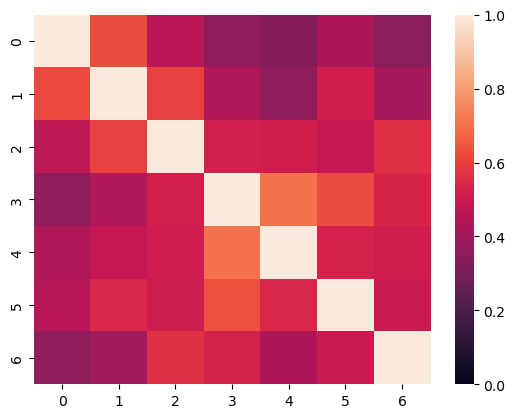

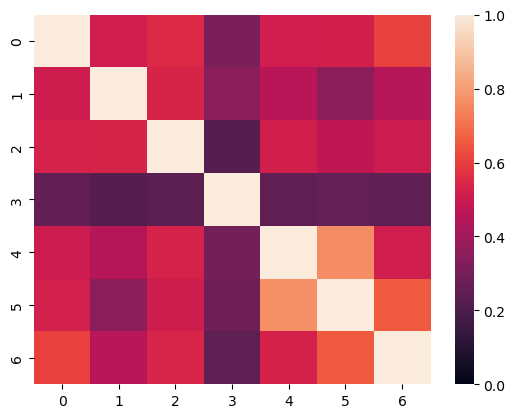

In [176]:
sb.heatmap(correlations_by_mouse['Right ear_R2'],vmin=0,vmax=1)
plt.savefig(dirname/ 'Right ear/R2' / 'curvature_persistence_by_delay.svg')
plt.figure()
sb.heatmap(correlations_by_mouse['Left ear_R2'],vmin=0,vmax=1)
plt.savefig(dirname/ 'Left ear/R2' / 'curvature_persistence_by_delay.svg')

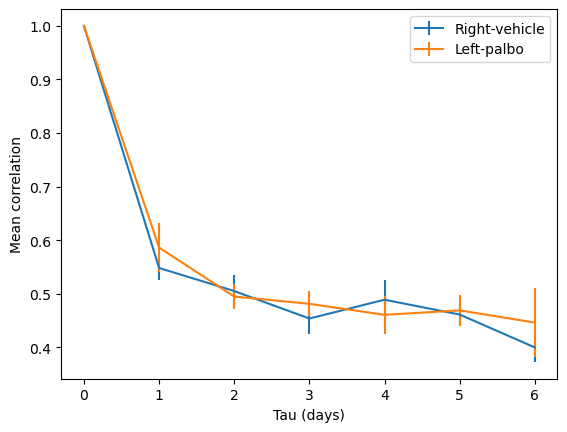

In [174]:
from itertools import product

diffs = np.array([tau - upsilon for tau in range(10) for upsilon in range(10)]).reshape((10,10)).astype(float)
diffs[diffs < 0] = np.nan
diffs[3,:] = np.nan
diffs[:,3] = np.nan

correlations_by_mouse_delay = {}
stds_by_mouse_delay = {}
for mouse in ['Right ear_R2','Left ear_R2']:
    R = np.zeros(7)
    sem = np.zeros(7)
    for delay in range(7):
        I = diffs == delay
        R[delay] = correlations_by_mouse[mouse][I].mean()
        sem[delay] = correlations_by_mouse[mouse][I].std() / np.sqrt(I.sum())
    correlations_by_mouse_delay[mouse] = R
    stds_by_mouse_delay[mouse] = sem

plt.errorbar(range(7),correlations_by_mouse_delay['Right ear_R2'],stds_by_mouse_delay['Right ear_R2'])
plt.errorbar(range(7),correlations_by_mouse_delay['Left ear_R2'],stds_by_mouse_delay['Left ear_R2'])
plt.legend(['Right-vehicle','Left-palbo'])
plt.xlabel('Tau (days)')
plt.ylabel('Mean correlation')

plt.savefig(dirname / 'curvature_persistence_by_delay.svg')